# Analysis of files sizes and size for every source per number of files and size

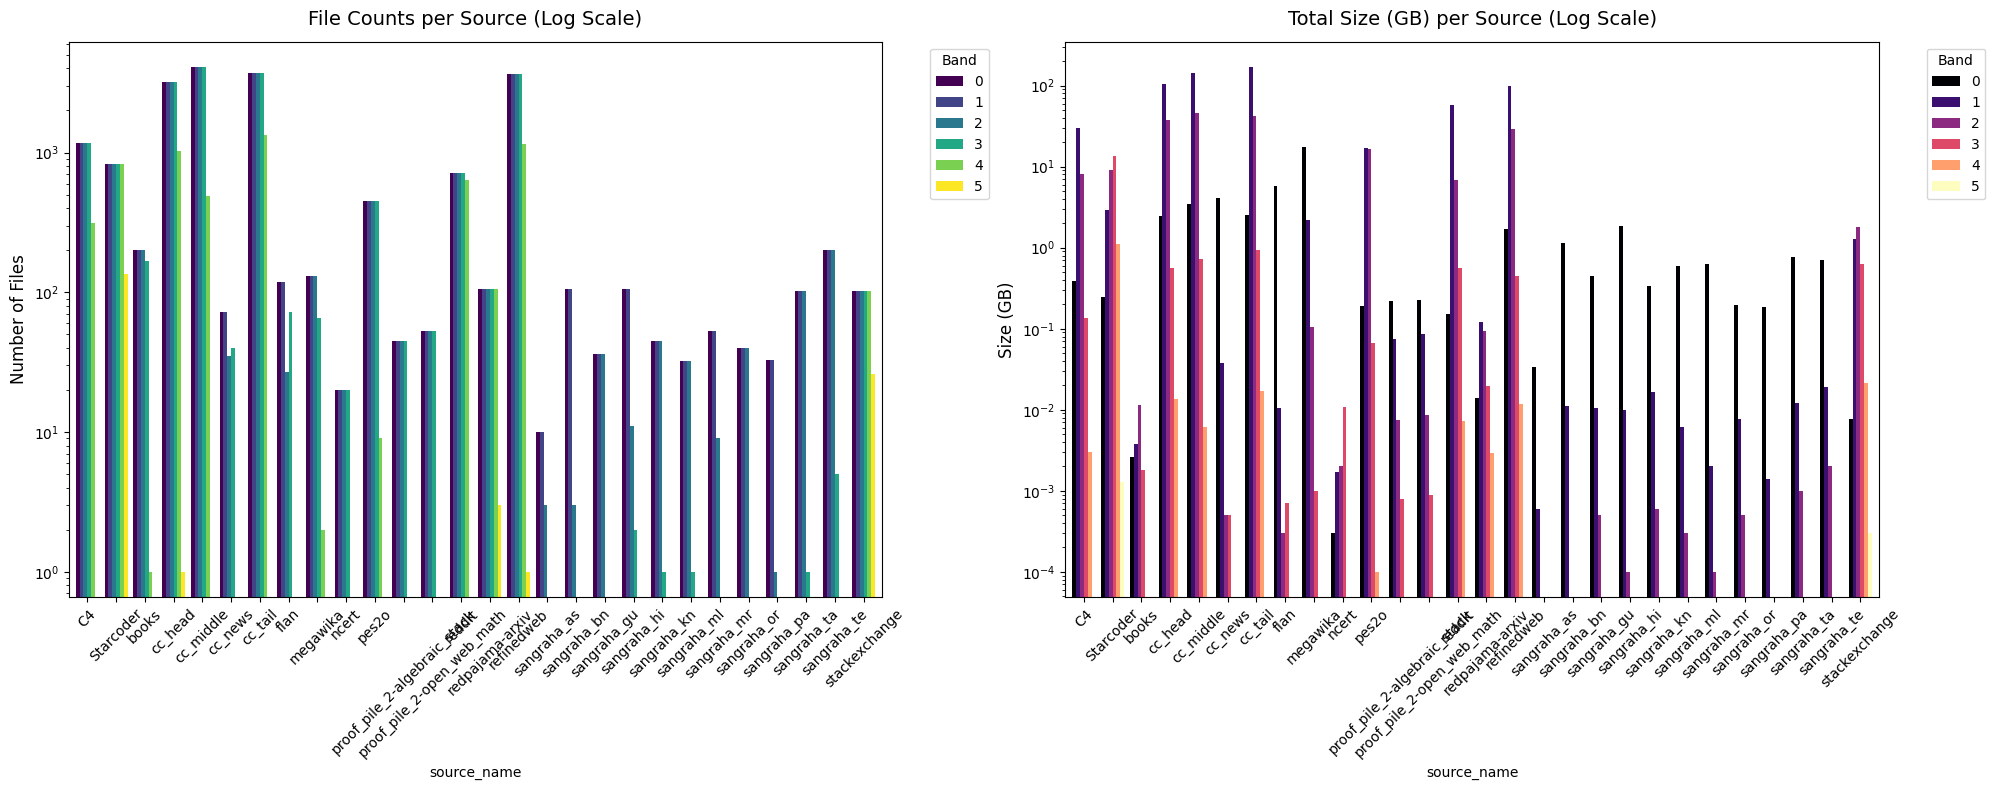

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('data/s3_counts_with_size.csv')

# 2. Pivot the data to group bands side-by-side for every source
pivot_files = df.pivot(index='source_name', columns='band_number', values='files_count')
pivot_size  = df.pivot(index='source_name', columns='band_number', values='total_size_gb')

# 3. Create a 1x2 grid and plot everything in ONE CELL
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot A: Number of Files (log scale)
pivot_files.plot(kind='bar', ax=axes[0], colormap='viridis', width=0.8)
axes[0].set_title('File Counts per Source (Log Scale)', fontsize=14, pad=12)
axes[0].set_ylabel('Number of Files', fontsize=12)
axes[0].set_yscale('log')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Band', bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot B: Total Size (log scale)
pivot_size.plot(kind='bar', ax=axes[1], colormap='magma', width=0.8)
axes[1].set_title('Total Size (GB) per Source (Log Scale)', fontsize=14, pad=12)
axes[1].set_ylabel('Size (GB)', fontsize=12)
axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Band', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

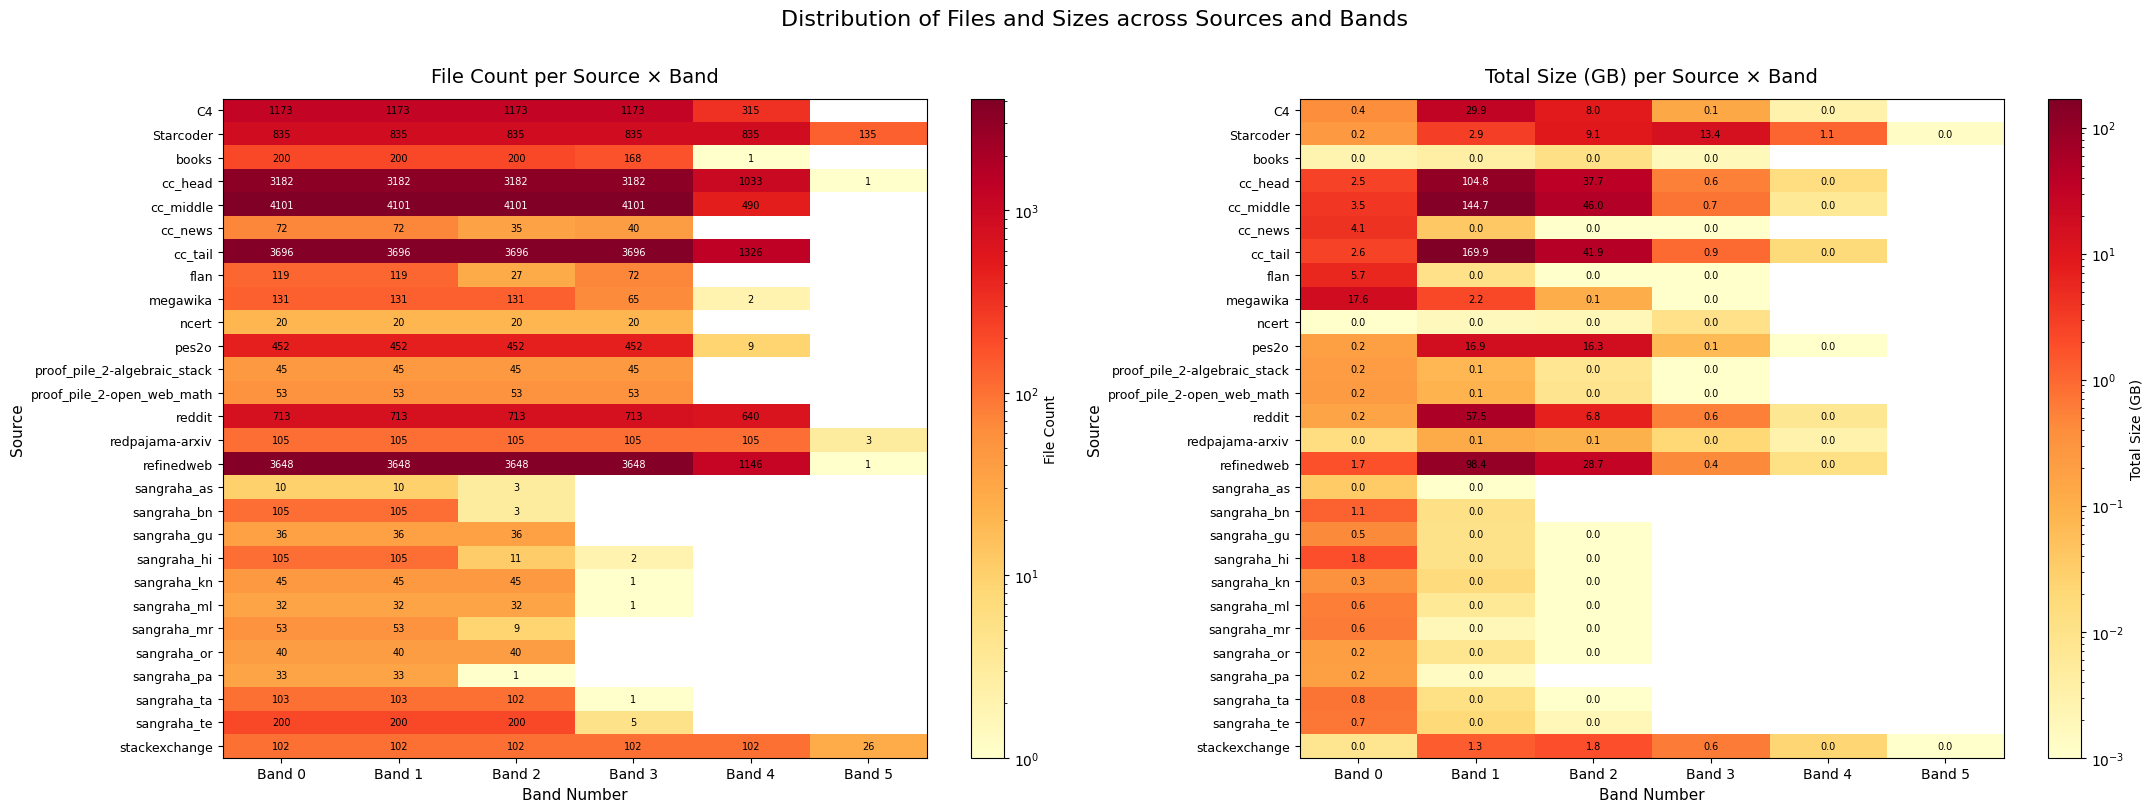

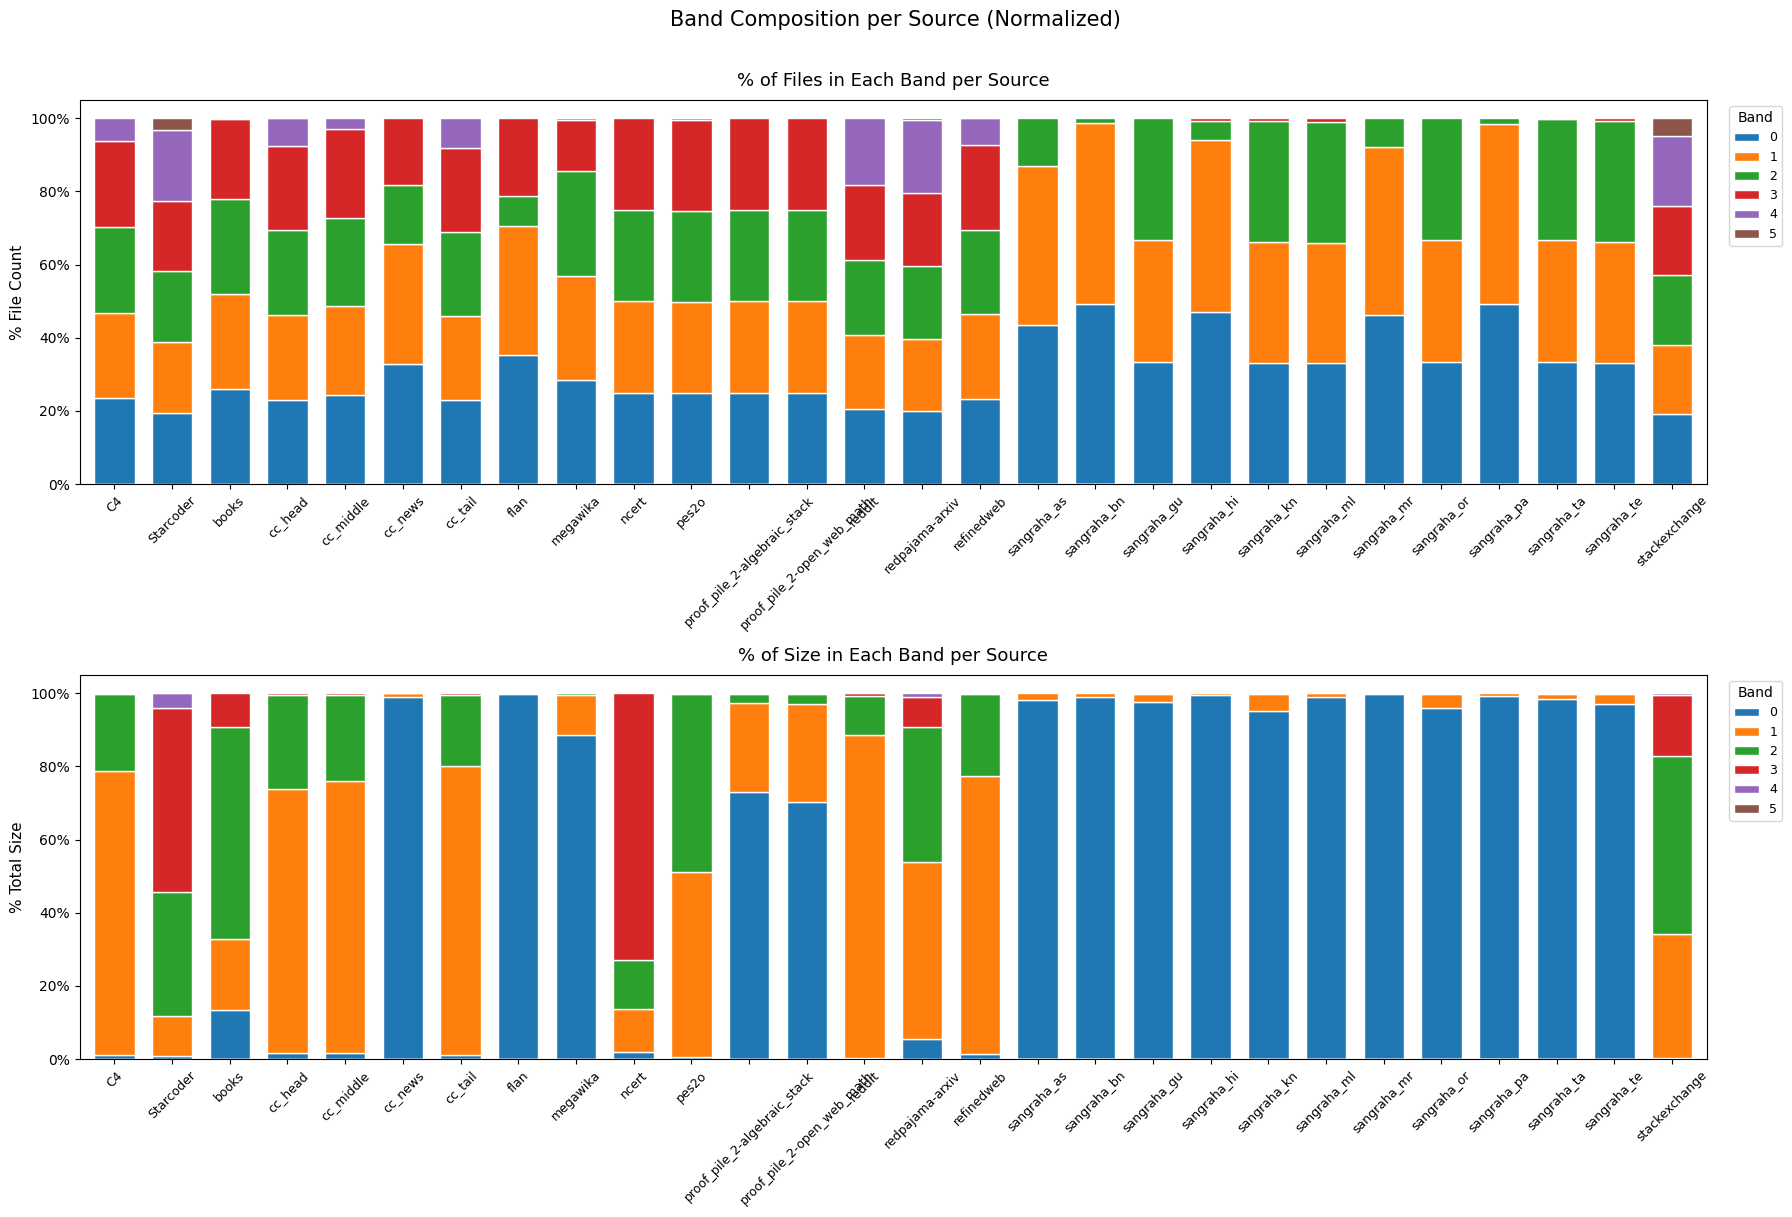

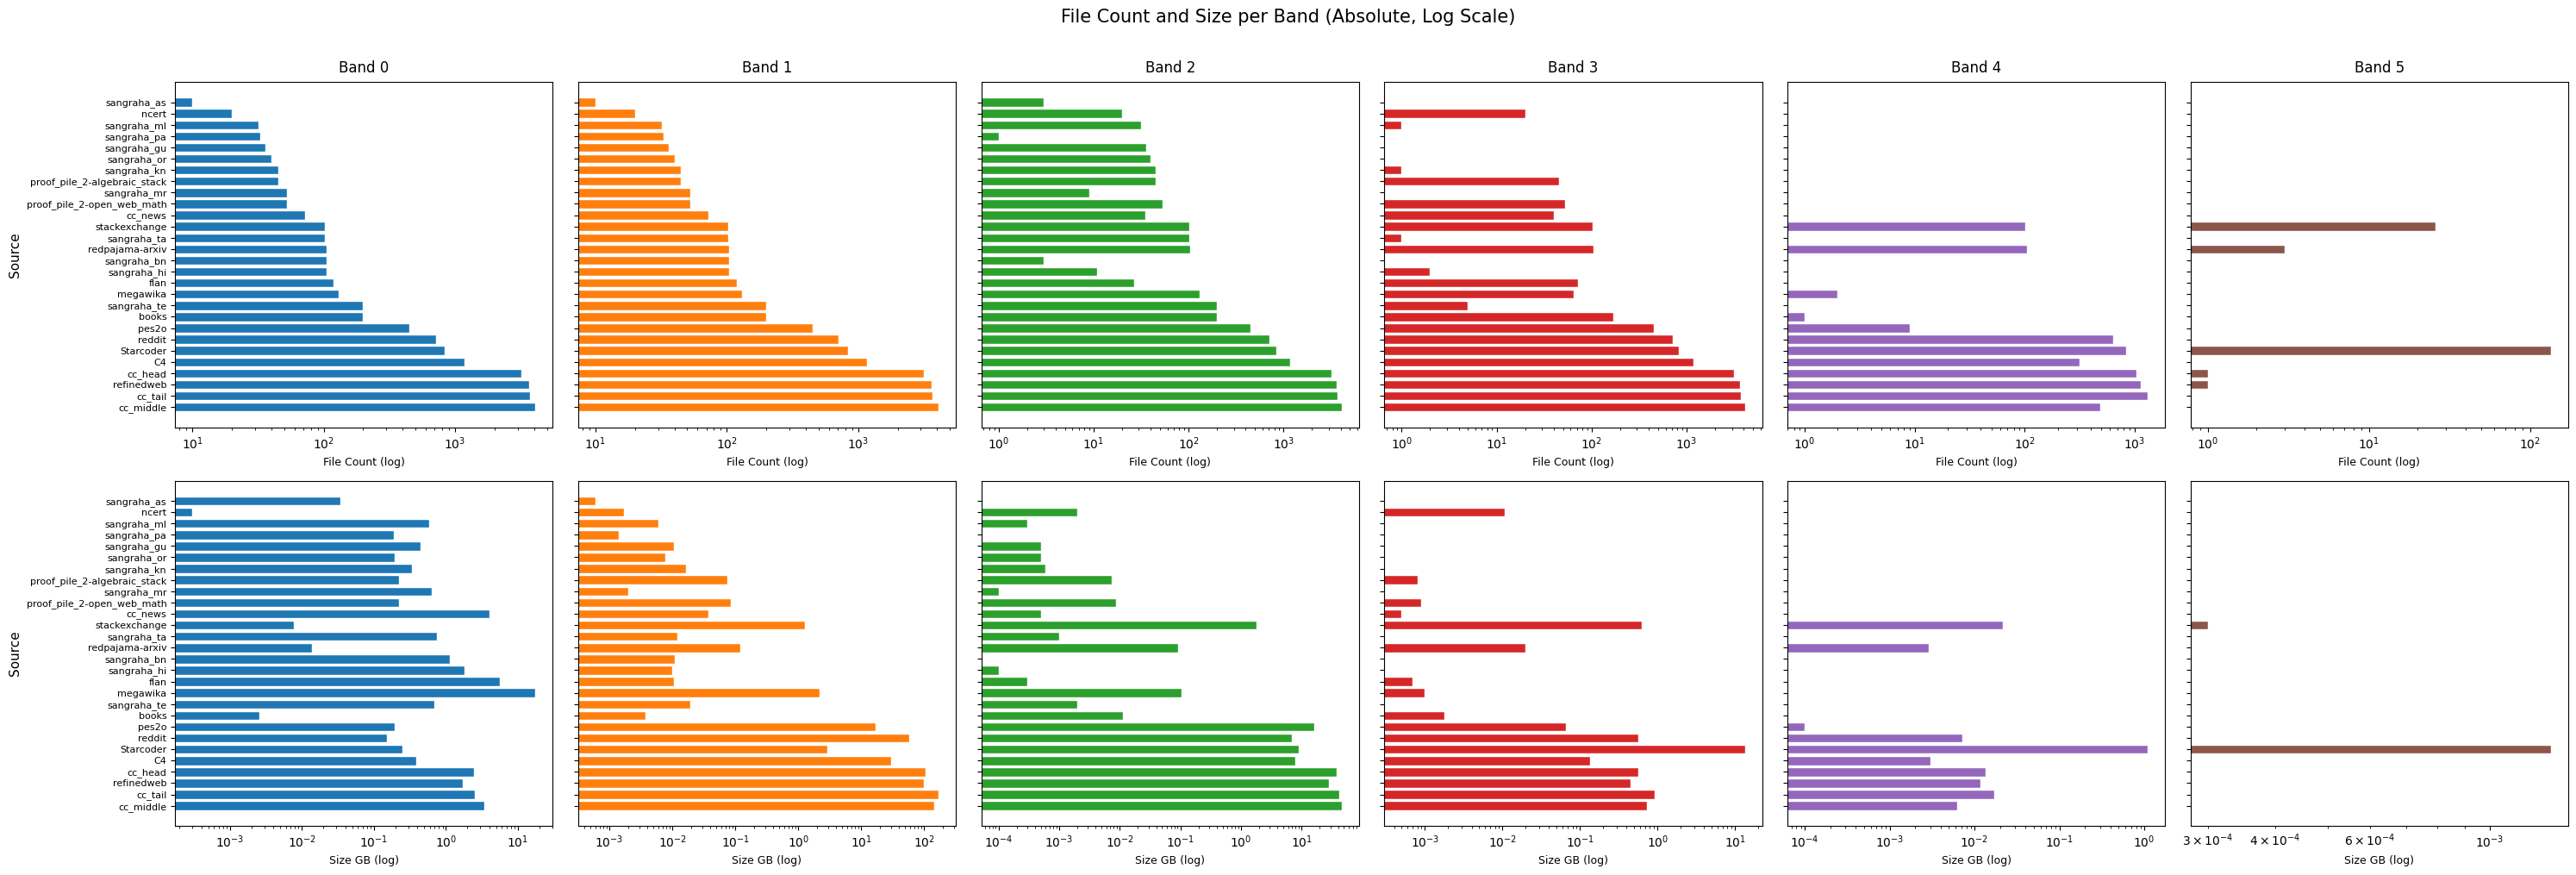

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

df = pd.read_csv('data/s3_counts_with_size.csv')

pivot_files = df.pivot(index='source_name', columns='band_number', values='files_count')
pivot_size  = df.pivot(index='source_name', columns='band_number', values='total_size_gb')

# ─── PLOT 1: Heatmaps (best for source × band overview) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

for ax, pivot, title, fmt in [
    (axes[0], pivot_files, 'File Count per Source × Band', '{:.0f}'),
    (axes[1], pivot_size,  'Total Size (GB) per Source × Band', '{:.1f}'),
]:
    # Use log-normalized color scale so small values are still visible
    data = pivot.fillna(0).values
    norm = mcolors.LogNorm(vmin=max(data[data > 0].min(), 1e-3), vmax=data.max())
    im = ax.imshow(data, aspect='auto', cmap='YlOrRd', norm=norm)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'Band {b}' for b in pivot.columns], fontsize=10)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel('Band Number', fontsize=11)
    ax.set_ylabel('Source', fontsize=11)
    plt.colorbar(im, ax=ax, label=title.split('per')[0].strip())
    # Annotate cells
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            val = data[r, c]
            if val > 0:
                ax.text(c, r, fmt.format(val), ha='center', va='center',
                        fontsize=7, color='black' if val < data.max() * 0.6 else 'white')

plt.suptitle('Distribution of Files and Sizes across Sources and Bands', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('heatmap_source_band.png', dpi=150, bbox_inches='tight')
plt.show()


# ─── PLOT 2: Normalized stacked bars (band composition per source) ─────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 12))
cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in range(len(pivot_files.columns))]

for ax, pivot, title, ylabel in [
    (axes[0], pivot_files, '% of Files in Each Band per Source', '% File Count'),
    (axes[1], pivot_size,  '% of Size in Each Band per Source',  '% Total Size'),
]:
    pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    pct.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.7, edgecolor='white')
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.legend(title='Band', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.suptitle('Band Composition per Source (Normalized)', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('stacked_band_composition.png', dpi=150, bbox_inches='tight')
plt.show()


# ─── PLOT 3: Faceted by band — absolute values with log scale ─────────────────
bands = sorted(df['band_number'].unique())
n_bands = len(bands)
fig, axes = plt.subplots(2, n_bands, figsize=(5 * n_bands, 10), sharey='row')

for col, band in enumerate(bands):
    band_df = df[df['band_number'] == band].sort_values('files_count', ascending=False)

    # Top row: file counts
    axes[0, col].barh(band_df['source_name'], band_df['files_count'],
                      color=cmap(col), edgecolor='white')
    axes[0, col].set_title(f'Band {band}', fontsize=12, pad=8)
    axes[0, col].set_xscale('log')
    if col == 0:
        axes[0, col].set_ylabel('Source', fontsize=11)
    axes[0, col].tick_params(axis='y', labelsize=8)
    axes[0, col].set_xlabel('File Count (log)', fontsize=9)

    # Bottom row: size
    axes[1, col].barh(band_df['source_name'], band_df['total_size_gb'],
                      color=cmap(col), edgecolor='white')
    axes[1, col].set_xscale('log')
    if col == 0:
        axes[1, col].set_ylabel('Source', fontsize=11)
    axes[1, col].tick_params(axis='y', labelsize=8)
    axes[1, col].set_xlabel('Size GB (log)', fontsize=9)

plt.suptitle('File Count and Size per Band (Absolute, Log Scale)', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('faceted_by_band.png', dpi=150, bbox_inches='tight')
plt.show()
